# Sprint 2 — Modelado y Evaluación
**Proyecto:** Clasificación de Tipos de Frijol (Dry Bean Dataset)  
**Prerequisito:** Haber ejecutado `sprint1_comprension_preparacion.ipynb`  

---
### Tareas del Sprint
- Cargar datos limpios del Sprint 1
- Entrenar modelo baseline (Logistic Regression)
- Entrenar modelo final (Random Forest)
- Evaluar Accuracy y F1 Macro
- Comparar ambos modelos
- Generar matriz de confusión
- Analizar importancia de variables

### Entregables
- Tabla comparativa de modelos
- Gráficas de métricas, matriz de confusión e importancia de variables
- Modelo final listo para el Sprint 3

## 1. Imports y Carga de Datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)

print("Librerías cargadas.")

Librerías cargadas.


In [ ]:
# Carga de los archivos generados en el Sprint 1
X_train = pd.read_csv("data/processed/X_train.csv")
X_test  = pd.read_csv("data/processed/X_test.csv")
y_train = pd.read_csv("data/processed/y_train.csv").squeeze()  # Serie, no DataFrame
y_test  = pd.read_csv("data/processed/y_test.csv").squeeze()

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Clases  : {sorted(y_train.unique())}")

X_train : (10834, 16)
X_test  : (2709, 16)
Clases  : ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']


## 2. Modelo Baseline — Logistic Regression

> **¿Por qué empezar con Logistic Regression?**  
> Es rápida, interpretable y establece una línea base razonable.  
> Se usa `StandardScaler` dentro de un `Pipeline` para evitar data leakage.

In [ ]:
baseline_model = Pipeline(steps=[
    ("scaler",     StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

baseline_model.fit(X_train, y_train)
print("Logistic Regression entrenado.")

Logistic Regression entrenado.


In [ ]:
y_pred_baseline = baseline_model.predict(X_test)

acc_baseline = accuracy_score(y_test, y_pred_baseline)
f1_baseline  = f1_score(y_test, y_pred_baseline, average="macro")

print(f"Accuracy  (baseline): {acc_baseline:.4f}")
print(f"F1 Macro  (baseline): {f1_baseline:.4f}")
print()
print(classification_report(y_test, y_pred_baseline))

Accuracy  (baseline): 0.9195
F1 Macro  (baseline): 0.9306

              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.86      0.89      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



## 3. Modelo Final — Random Forest

> **¿Por qué Random Forest?**  
> - Captura relaciones no lineales entre variables geométricas.  
> - `class_weight='balanced'` pondera clases minoritarias sin resampling.  
> - Proporciona importancia de variables para interpretabilidad.

In [ ]:
forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

forest_model.fit(X_train, y_train)
print("Random Forest entrenado.")

Random Forest entrenado.


In [ ]:
y_pred_forest = forest_model.predict(X_test)

acc_forest = accuracy_score(y_test, y_pred_forest)
f1_forest  = f1_score(y_test, y_pred_forest, average="macro")

print(f"Accuracy  (Random Forest): {acc_forest:.4f}")
print(f"F1 Macro  (Random Forest): {f1_forest:.4f}")
print()
print(classification_report(y_test, y_pred_forest))

Accuracy  (Random Forest): 0.9192
F1 Macro  (Random Forest): 0.9303

              precision    recall  f1-score   support

    BARBUNYA       0.92      0.89      0.90       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.94      0.93       326
    DERMASON       0.91      0.92      0.92       709
       HOROZ       0.96      0.95      0.95       372
       SEKER       0.95      0.95      0.95       406
        SIRA       0.87      0.86      0.86       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



## 4. Comparación de Modelos

In [ ]:
results = pd.DataFrame({
    "Modelo"  : ["Logistic Regression", "Random Forest"],
    "Accuracy": [acc_baseline, acc_forest],
    "F1 Macro": [f1_baseline,  f1_forest]
})
print(results.to_string(index=False))

mejor = results.loc[results["F1 Macro"].idxmax(), "Modelo"]
print(f"\nMejor modelo por F1 Macro: {mejor}")

             Modelo  Accuracy  F1 Macro
Logistic Regression  0.919528  0.930551
      Random Forest  0.919158  0.930340

Mejor modelo por F1 Macro: Logistic Regression


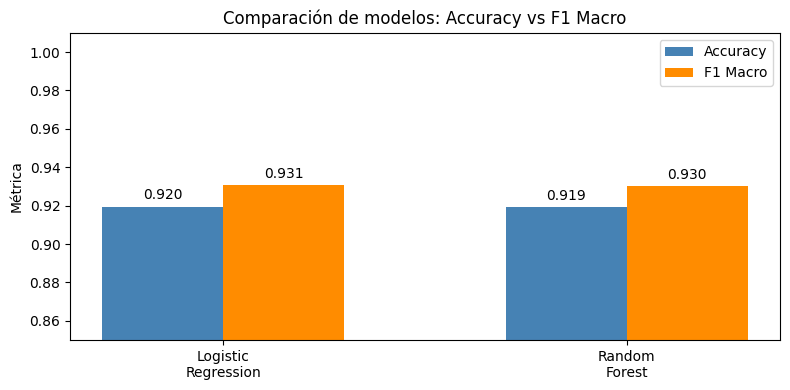

Gráfica guardada como 'comparacion_modelos.png'


In [ ]:
# Gráfica comparativa de métricas
fig, ax = plt.subplots(figsize=(8, 4))

x     = np.arange(2)
width = 0.3
modelos = ["Logistic\nRegression", "Random\nForest"]

bars1 = ax.bar(x - width/2, [acc_baseline, acc_forest], width, label="Accuracy", color="steelblue")
bars2 = ax.bar(x + width/2, [f1_baseline,  f1_forest],  width, label="F1 Macro", color="darkorange")

ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.set_ylim(0.85, 1.01)
ax.set_ylabel("Métrica")
ax.set_title("Comparación de modelos: Accuracy vs F1 Macro")
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)

plt.tight_layout()
plt.savefig("outputs/reports/comparacion_modelos.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada como 'outputs/reports/comparacion_modelos.png'")

## 5. Matriz de Confusión (Random Forest)

> Permite identificar qué clases se confunden más entre sí.

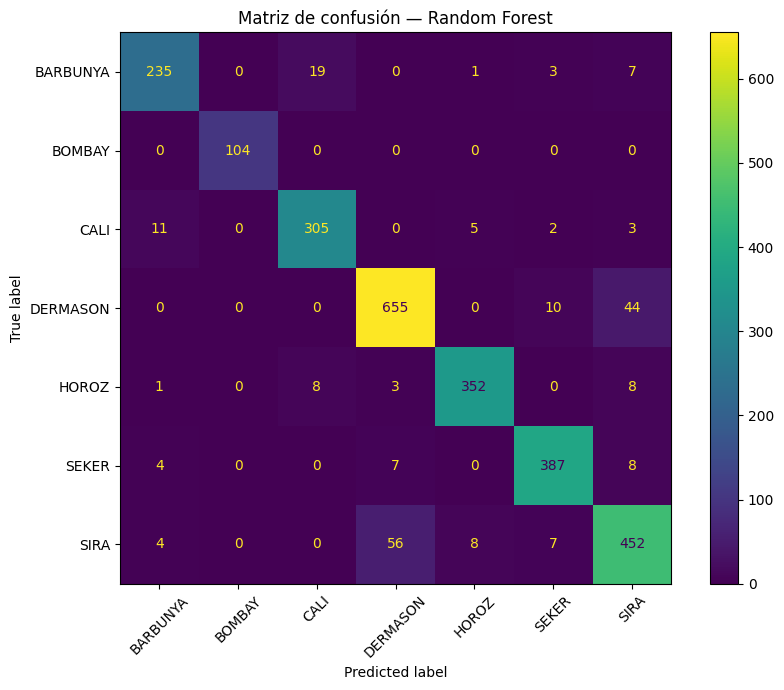

Gráfica guardada como 'matriz_confusion.png'


In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_forest,
    xticks_rotation=45,
    ax=ax
)
ax.set_title("Matriz de confusión — Random Forest")

plt.tight_layout()
plt.savefig("outputs/reports/matriz_confusion.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada como 'outputs/reports/matriz_confusion.png'")

### Análisis de la Matriz de Confusión

> **Clases que más se confunden:** DERMASON ↔ SIRA  
> **Motivo:** Ambas variedades comparten perfiles geométricos muy similares en área, perímetro, redondez y longitud de ejes. El modelo trabaja exclusivamente con estas variables numéricas, por lo que la separación matemática se vuelve difícil cuando las distribuciones se superponen.

## 6. Importancia de Variables (Random Forest)

In [ ]:
feature_importance = pd.DataFrame({
    "feature"   : X_train.columns,
    "importance": forest_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("Top 10 variables más importantes:")
print(feature_importance.head(10).to_string(index=False))

Top 10 variables más importantes:
        feature  importance
      Perimeter    0.110626
   ShapeFactor1    0.103799
    Compactness    0.100588
   ShapeFactor3    0.096586
MinorAxisLength    0.082270
  EquivDiameter    0.065426
   Eccentricity    0.063598
      Roundness    0.060568
     ConvexArea    0.058507
           Area    0.058484


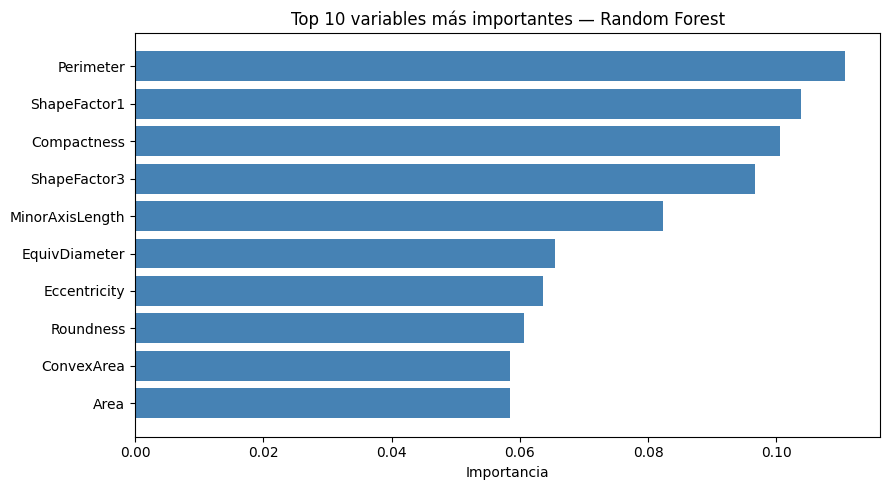

Gráfica guardada como 'importancia_variables.png'


In [ ]:
top10 = feature_importance.head(10)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top10["feature"][::-1], top10["importance"][::-1], color="steelblue")
ax.set_xlabel("Importancia")
ax.set_title("Top 10 variables más importantes — Random Forest")

plt.tight_layout()
plt.savefig("outputs/reports/importancia_variables.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada como 'outputs/reports/importancia_variables.png'")

## 7. Guardar Modelo para el Sprint 3

In [ ]:
import joblib

joblib.dump(forest_model, "outputs/models/random_forest_drybean.joblib")

print("Entregables del Sprint 2:")
print("    random_forest_drybean.joblib  — modelo entrenado")
print("    comparacion_modelos.png")
print("    matriz_confusion.png")
print("    importancia_variables.png")
print()
print("Sprint 2 completado. Continúa con: sprint3_despliegue_documentacion.ipynb")

Entregables del Sprint 2:
    random_forest_drybean.joblib  — modelo entrenado
    comparacion_modelos.png
    matriz_confusion.png
    importancia_variables.png

Sprint 2 completado. Continúa con: sprint3_despliegue_documentacion.ipynb
